# 📊 Notebook 05 — Comparison Analysis
## Bagian 5: Evaluasi Komparatif + Bagian 6: Analisis Domain

**Tujuan:**
1. Tabel ringkasan top 10 kombinasi
2. Quadrant plot: F1 vs Training Time
3. Error analysis pada top 3 kombinasi
4. Class imbalance handling (ablation study)
5. Topic modeling LDA pada review negatif
6. Temporal analysis

## Setup

In [50]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluator import (
    plot_comparison_quadrant, plot_confusion_matrix,
    error_analysis, print_top_results, plot_wordcloud
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

## Load Comparison Results

In [51]:
# Load tabel komparasi final; prioritaskan hasil balanced jika tersedia
preferred_results_path = '../results/comparison_table.csv'
fallback_results_path = '../results/comparison_table.csv'

results_path = preferred_results_path if os.path.exists(preferred_results_path) else fallback_results_path
comparison_df = pd.read_csv(results_path)

if 'Rank' in comparison_df.columns:
    comparison_df = comparison_df.set_index('Rank')
else:
    comparison_df.index = np.arange(1, len(comparison_df) + 1)
    comparison_df.index.name = 'Rank'

print(f"📊 Total kombinasi: {len(comparison_df)}")
print(f"📁 Sumber hasil: {os.path.basename(results_path)}")
print(comparison_df.head(10).to_string())

📊 Total kombinasi: 6
📁 Sumber hasil: comparison_table.csv
     feature_extractor          model  weighted_f1  macro_f1   roc_auc  accuracy  train_time_s  infer_time_ms                                                                                                              best_params
Rank                                                                                                                                                                                                                                  
1             Word2Vec        XGBoost     0.639158  0.639443  0.805060  0.639344         22.81           5.58  {'subsample': 0.7, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
2             Word2Vec  Random Forest     0.618077  0.618413  0.815386  0.622951          2.19         190.36                                    {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
3             Word

## 5.1 — Top 10 Kombinasi Terbaik

In [52]:
print_top_results(comparison_df, n=10)


🏆 Top 10 Kombinasi Terbaik (Weighted F1):
Rank |  Feature Extractor |                  Model |   W-F1 |   M-F1 |    AUC | Train(s)
------------------------------------------------------------------------------------------
   1 |           Word2Vec |                XGBoost | 0.6392 | 0.6394 | 0.8051 |     22.8
   2 |           Word2Vec |          Random Forest | 0.6181 | 0.6184 | 0.8154 |      2.2
   3 |           Word2Vec |          Decision Tree | 0.5738 | 0.5737 | 0.7227 |      0.1
   4 |           FastText |          Random Forest | 0.5286 | 0.5283 | 0.6702 |      2.2
   5 |           FastText |                XGBoost | 0.5216 | 0.5220 | 0.7243 |     19.3
   6 |           FastText |          Decision Tree | 0.5064 | 0.5058 | 0.6416 |      2.9


## Quadrant Plot: Performance vs Efficiency

   💾 Saved: ../results/figures/evaluation/quadrant_f1_vs_time.png


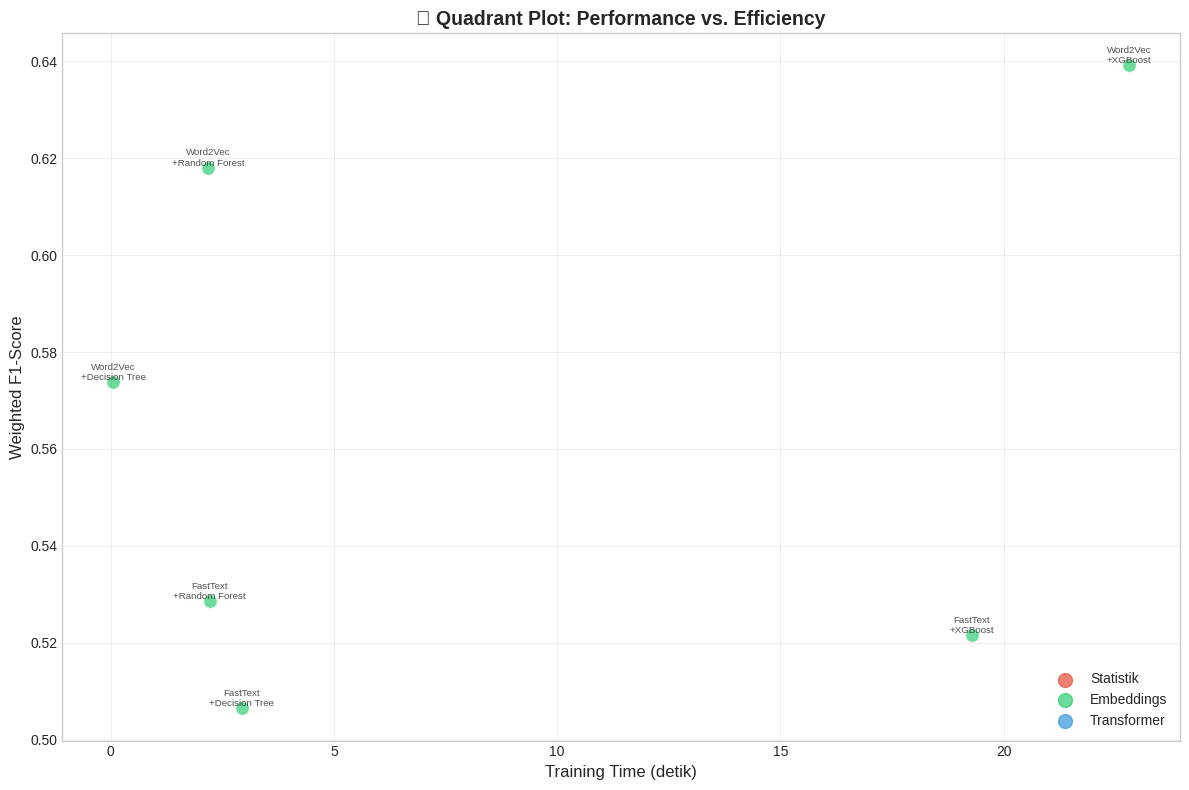

In [53]:
plot_comparison_quadrant(
    comparison_df,
    save_path='../results/figures/evaluation/quadrant_f1_vs_time.png'
)

## Grouped Bar Chart: F1 per Model per Feature Extractor

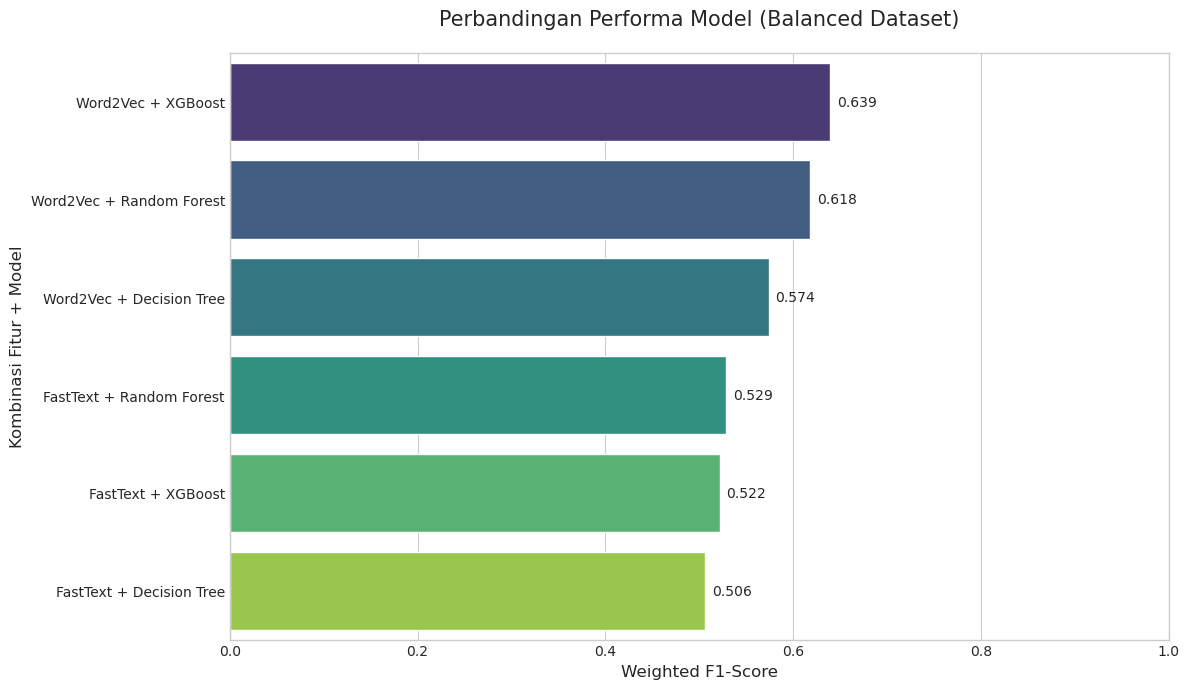

✅ Visualisasi diperbarui: ../results/figures/evaluation/grouped_bar_f1.png


In [54]:
# Gunakan hasil yang sudah dimuat pada bagian awal agar seluruh analisis konsisten
plot_df = comparison_df.reset_index(drop=True).copy()

# Create a clear combination name
plot_df['Combination'] = plot_df['feature_extractor'] + " + " + plot_df['model']

# Sort by Weighted F1
comparison_df_sorted = plot_df.sort_values('weighted_f1', ascending=False)

# Setup plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create Bar Plot
ax = sns.barplot(
    x='weighted_f1', 
    y='Combination', 
    data=comparison_df_sorted, 
    palette='viridis'
)

# Add labels
plt.title('Perbandingan Performa Model (Balanced Dataset)', fontsize=15, pad=20)
plt.xlabel('Weighted F1-Score', fontsize=12)
plt.ylabel('Kombinasi Fitur + Model', fontsize=12)
plt.xlim(0, 1.0)

# Add values on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5)

plt.tight_layout()

# Save updated figure
output_path = '../results/figures/evaluation/grouped_bar_f1.png'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path, dpi=300)
plt.show()

print(f"✅ Visualisasi diperbarui: {output_path}")

## 5.2 — Error Analysis (Top 3 Kombinasi)

In [55]:
# Load data untuk error analysis
df = pd.read_csv('../data/processed/reviews_prepared.csv')
texts = df['review_clean'].fillna('').tolist()

# Info tentang top 3
top3 = comparison_df.head(3)
print("\n🔍 Error Analysis akan dilakukan pada Top 3 kombinasi:")
for idx, row in top3.iterrows():
    print(f"   #{idx}: {row['feature_extractor']} + {row['model']} "
          f"(W-F1={row['weighted_f1']:.4f})")

print("\n⚠️  Untuk menjalankan error analysis secara detail,")
print("   re-train model top 3 dan kumpulkan prediksi y_pred.")
print("   Gunakan src.evaluator.error_analysis() setelah re-training.")


🔍 Error Analysis akan dilakukan pada Top 3 kombinasi:
   #1: Word2Vec + XGBoost (W-F1=0.6392)
   #2: Word2Vec + Random Forest (W-F1=0.6181)
   #3: Word2Vec + Decision Tree (W-F1=0.5738)

⚠️  Untuk menjalankan error analysis secara detail,
   re-train model top 3 dan kumpulkan prediksi y_pred.
   Gunakan src.evaluator.error_analysis() setelah re-training.


## 5.3 — Class Imbalance Handling (Ablation Study)

In [56]:
print("\n📊 Class Imbalance Ablation Study")
print("=" * 60)
print("""
Strategi yang diuji:
A. Baseline: Tanpa penanganan (class_weight=None)
B. Class Weight: class_weight='balanced'
C. Oversampling: SMOTE (hanya untuk dense features)
D. Undersampling: RandomUnderSampler
E. Combined: SMOTEENN

⚠️  Untuk menjalankan ablation study lengkap,
   pilih model terbaik dari Top 3 dan jalankan
   masing-masing strategi secara terpisah.
""")

# Contoh kode untuk ablation study:
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.combine import SMOTEENN
#
# # Untuk dense features (FastText, IndoBERT):
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train_dense, y_train)
# print(f"SMOTE: {np.bincount(y_train_res)}")


📊 Class Imbalance Ablation Study

Strategi yang diuji:
A. Baseline: Tanpa penanganan (class_weight=None)
B. Class Weight: class_weight='balanced'
C. Oversampling: SMOTE (hanya untuk dense features)
D. Undersampling: RandomUnderSampler
E. Combined: SMOTEENN

⚠️  Untuk menjalankan ablation study lengkap,
   pilih model terbaik dari Top 3 dan jalankan
   masing-masing strategi secara terpisah.



## 6.1 — Topic Modeling LDA pada Review Negatif

In [57]:
print("\n📊 Topic Modeling — Review Negatif")
print("=" * 60)

# Filter review negatif
df_neg = df[df['sentiment'] == 'Negatif']
print(f"   Total review negatif: {len(df_neg)}")


📊 Topic Modeling — Review Negatif
   Total review negatif: 203


   Vocabulary size: 108
   Corpus size: 203

   Mencari jumlah topik optimal...
      Topics=3: coherence=0.3114
      Topics=4: coherence=0.3176
      Topics=5: coherence=0.3209
      Topics=6: coherence=0.3061
      Topics=7: coherence=0.3095
      Topics=8: coherence=0.3315
      Topics=9: coherence=0.3245
      Topics=10: coherence=0.3399
      Topics=11: coherence=0.3080
      Topics=12: coherence=0.3306


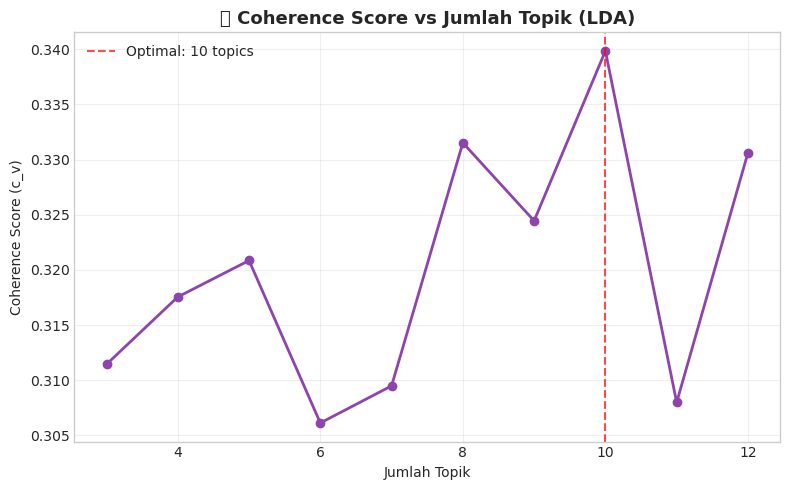


   Training LDA dengan 10 topik...

📋 Top 10 kata per topik:
   Topik 1: ribet, aplikasi, npwp, susah, login, daftar, pemerintah, saja, tapi, begini
   Topik 2: chat, aplikasi, error, live, buka, pajak, mau, sangat, web, baru
   Topik 3: login, tolong, mau, perbaiki, apa, orang, saja, lagi, aplikasi, belum
   Topik 4: kode, verifikasi, sama, sekali, email, otp, lama, aplikasi, masuk, lemot
   Topik 5: aplikasi, pajak, mau, lapor, sangat, bayar, masuk, efin, pemerintah, saja
   Topik 6: login, tapi, gagal, sangat, selalu, sama, verifikasi, kali, data, gw
   Topik 7: aplikasi, terus, saja, harus, guna, padahal, lagi, eror, bikin, pajak
   Topik 8: email, terus, gagal, nomor, aktivasi, handphone, lupa, dibuka, aplikasi, saat
   Topik 9: aplikasi, pajak, salah, tapi, login, semua, malah, orang, mempersulit, saja
   Topik 10: saja, mau, aplikasi, apa, bagaimana, bikin, lagi, web, sangat, daftar


In [58]:
# LDA Topic Modeling
try:
    from gensim import corpora
    from gensim.models import LdaMulticore
    from gensim.models.coherencemodel import CoherenceModel

    # Prepare corpus
    texts_neg = df_neg['review_clean'].fillna('').apply(str.split).tolist()
    texts_neg = [t for t in texts_neg if len(t) > 0]

    dictionary = corpora.Dictionary(texts_neg)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in texts_neg]

    print(f"   Vocabulary size: {len(dictionary)}")
    print(f"   Corpus size: {len(corpus)}")

    # Test berbagai jumlah topik
    coherence_scores = []
    topic_range = range(3, 13)
    print("\n   Mencari jumlah topik optimal...")

    for n_topics in topic_range:
        lda = LdaMulticore(
            corpus, num_topics=n_topics,
            id2word=dictionary, passes=10,
            workers=2, random_state=42
        )
        cm = CoherenceModel(model=lda, texts=texts_neg,
                            dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()
        coherence_scores.append(score)
        print(f"      Topics={n_topics}: coherence={score:.4f}")

    # Plot coherence
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(list(topic_range), coherence_scores, marker='o', linewidth=2, color='#8E44AD')
    best_n = list(topic_range)[np.argmax(coherence_scores)]
    ax.axvline(best_n, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_n} topics')
    ax.set_xlabel('Jumlah Topik')
    ax.set_ylabel('Coherence Score (c_v)')
    ax.set_title('🔍 Coherence Score vs Jumlah Topik (LDA)', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/figures/interpretation/lda_coherence.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Train model optimal
    print(f"\n   Training LDA dengan {best_n} topik...")
    best_lda = LdaMulticore(
        corpus, num_topics=best_n,
        id2word=dictionary, passes=20,
        workers=2, random_state=42
    )

    # Tampilkan topik
    print(f"\n📋 Top 10 kata per topik:")
    for topic_id in range(best_n):
        words = best_lda.show_topic(topic_id, topn=10)
        word_list = ', '.join([w for w, _ in words])
        print(f"   Topik {topic_id+1}: {word_list}")

except ImportError:
    print("   ⚠️  gensim tidak tersedia. Install: pip install gensim")
except Exception as e:
    print(f"   ❌ Error: {e}")

## 6.2 — Temporal Analysis


📊 Temporal Analysis


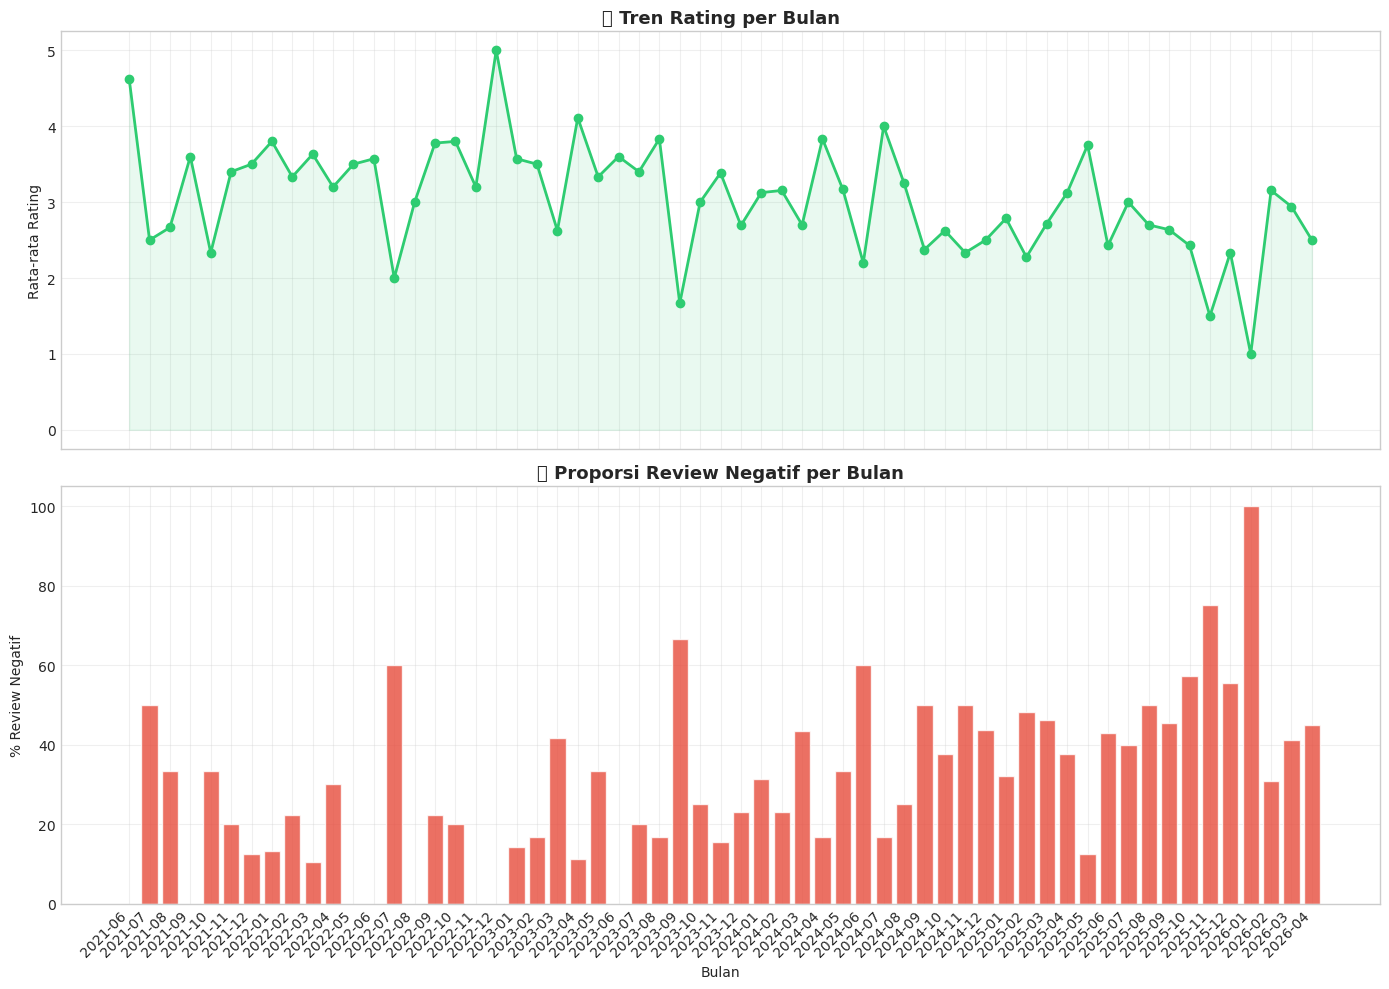

In [59]:
print("\n📊 Temporal Analysis")
print("=" * 60)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year_month_dt'] = df['date'].dt.to_period('M')

# Aggregate per bulan
monthly = df.groupby('year_month_dt').agg(
    count=('rating', 'size'),
    avg_rating=('rating', 'mean'),
    pct_negative=('sentiment', lambda x: (x == 'Negatif').mean() * 100)
).reset_index()

monthly['year_month_dt'] = monthly['year_month_dt'].astype(str)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Avg rating over time
axes[0].plot(monthly['year_month_dt'], monthly['avg_rating'],
             marker='o', linewidth=2, color='#2ECC71')
axes[0].fill_between(monthly['year_month_dt'], monthly['avg_rating'],
                     alpha=0.1, color='#2ECC71')
axes[0].set_ylabel('Rata-rata Rating')
axes[0].set_title('📈 Tren Rating per Bulan', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# % negative over time
axes[1].bar(monthly['year_month_dt'], monthly['pct_negative'],
            color='#E74C3C', edgecolor='white', alpha=0.8)
axes[1].set_ylabel('% Review Negatif')
axes[1].set_xlabel('Bulan')
axes[1].set_title('📉 Proporsi Review Negatif per Bulan', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/interpretation/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


📊 Analisis per App Version:


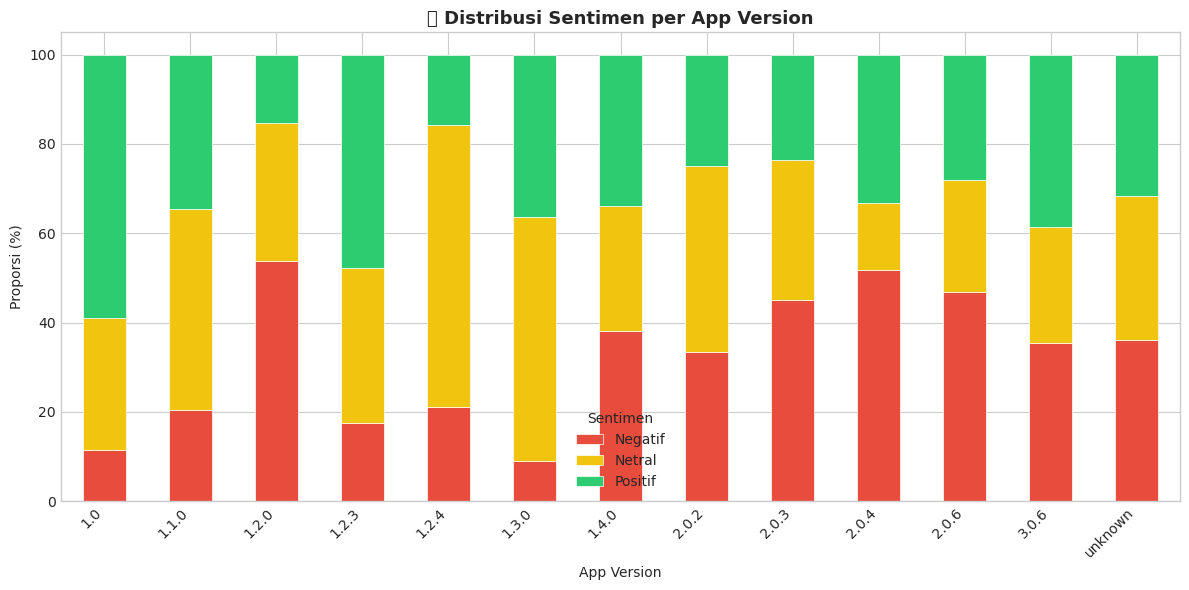

In [60]:
# App version analysis (jika tersedia)
if 'app_version' in df.columns:
    print("\n📊 Analisis per App Version:")
    version_sentiment = pd.crosstab(
        df['app_version'], df['sentiment'], normalize='index'
    ) * 100
    version_sentiment = version_sentiment.sort_index()

    # Hanya tampilkan versi dengan > 10 review
    version_counts = df['app_version'].value_counts()
    significant_versions = version_counts[version_counts > 10].index
    version_sentiment_filtered = version_sentiment.loc[
        version_sentiment.index.isin(significant_versions)
    ]

    if len(version_sentiment_filtered) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        version_sentiment_filtered[['Negatif', 'Netral', 'Positif']].plot(
            kind='bar', stacked=True, ax=ax,
            color=['#E74C3C', '#F1C40F', '#2ECC71'],
            edgecolor='white', linewidth=0.5
        )
        ax.set_xlabel('App Version')
        ax.set_ylabel('Proporsi (%)')
        ax.set_title('📊 Distribusi Sentimen per App Version', fontsize=13, fontweight='bold')
        ax.legend(title='Sentimen')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('../results/figures/interpretation/sentiment_by_version.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

## Ringkasan Analisis

| Aspek | Detail |
|-------|--------|
| Top kombinasi | Lihat `results/comparison_table.csv` |
| Quadrant plot | `results/figures/evaluation/quadrant_f1_vs_time.png` |
| LDA Topics | Review negatif dikelompokkan ke topik-topik keluhan |
| Temporal | Tren sentimen dari waktu ke waktu |

In [61]:
print("\n✅ Analisis komparatif selesai!")
print("   📂 Semua hasil tersimpan di folder results/")
print(f"   📋 Comparison table: {results_path}")
print("   📊 Visualisasi: results/figures/")


✅ Analisis komparatif selesai!
   📂 Semua hasil tersimpan di folder results/
   📋 Comparison table: ../results/comparison_table.csv
   📊 Visualisasi: results/figures/
